# CPS Labor Market Analysis

## Methodology
* Data source: IPUMS CPS Basic Monthly (2010–2024)
* Population: Individuals aged 18+ (22+ for career stage analysis)
* Weighting: All statistics use person weights (`WTFINL`)
* Unemployment defined as `EMPSTAT ∈ {20, 21, 22}`
* Unemployment duration measured using `DURUNEMP` (weeks)
* Results are reported as weighted averages
* Time trends are smoothed using a 3-year rolling average

### CPS limitations
The project hypothesis was that the tech industry was using AI resume filtering in recent years that may exacerbate challenges already faced by marginalized groups (older workers); however, occupation is not reliably defined for unemployed individuals in CPS, so unemployment outcomes are analyzed across the full labor market rather than within specific occupations.

## 1. Data Source

### Setup

In [34]:
import sys
from pathlib import Path

# Go from notebooks/ → project root
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "cps"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
import os
print(os.getcwd())
print(PROJECT_ROOT)

C:\Users\micro\Documents\Education\ucbai\ucbai-cs-resumefilter\notebooks
C:\Users\micro\Documents\Education\ucbai\ucbai-cs-resumefilter


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_processing.cps_processing import  (
    clean_cps_base,
    unemployment_summary_by_age,
    unemployment_summary_by_career_stage,
    unemployment_duration_by_group_over_time
)

### Load data

In [20]:
df = pd.read_parquet(DATA_DIR / "interim" / "cps_clean.parquet")

## 2. Data Preparation

In [21]:
df_clean = clean_cps_base(df)

In [41]:
df_clean.shape

(17721860, 22)

In [42]:
df_clean['AGE'].describe()

count    1.772186e+07
mean     4.884729e+01
std      1.814451e+01
min      1.800000e+01
25%      3.400000e+01
50%      4.900000e+01
75%      6.300000e+01
max      8.500000e+01
Name: AGE, dtype: float64

In [43]:
df_clean['WTFINL'].describe()

count    1.772186e+07
mean     2.685102e+03
std      1.546864e+03
min      4.930740e+01
25%      1.362158e+03
50%      2.869935e+03
75%      3.661253e+03
max      2.619413e+04
Name: WTFINL, dtype: float64

## 3. Results

In [22]:
summary_by_age = unemployment_summary_by_age(df_clean)
summary_by_age

,age_group,unemployment_rate,mean_unemployment_duration_weeks
0,<30,0.064669,21.904910
1,30-39,0.041525,27.175318
2,40-49,0.036451,30.038259
3,50+,0.019842,32.903249


In [23]:
summary_by_career_stage = unemployment_summary_by_career_stage(df_clean)
summary_by_career_stage

,career_stage,unemployment_rate,mean_unemployment_duration_weeks
0,22-32,0.055699,24.403550
1,33-42,0.039057,27.938379
2,43-52,0.035664,31.181147
3,52+,0.017962,32.962442


## 4. Time Trends

In [25]:
trend_age = unemployment_duration_by_group_over_time(df_clean, "age_group")
pivot_age = trend_age.pivot(index="YEAR", columns="age_group", values="mean_duration")
pivot_age

age_group,<30,30-39,40-49,50+
YEAR,,,,
2010,27.521491,33.637770,36.527823,40.615426
2011,29.166514,37.265953,41.016224,45.910428
2012,28.207031,36.133977,39.262593,45.658803
2013,26.237833,34.182249,36.400218,40.857182
2014,24.127784,30.063427,34.555467,38.237465
2015,21.119935,25.756727,29.315847,33.084504
2016,19.691655,23.563580,26.856302,31.277562
2017,17.595968,22.525338,24.571092,29.734536
2018,16.331834,20.392146,21.965335,27.132490


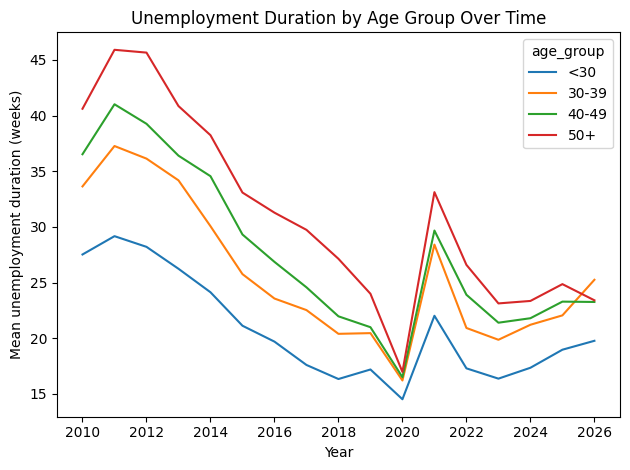

In [39]:
ax = pivot_age.plot(title="Unemployment Duration by Age Group Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean unemployment duration (weeks)")
ax.figure.tight_layout()

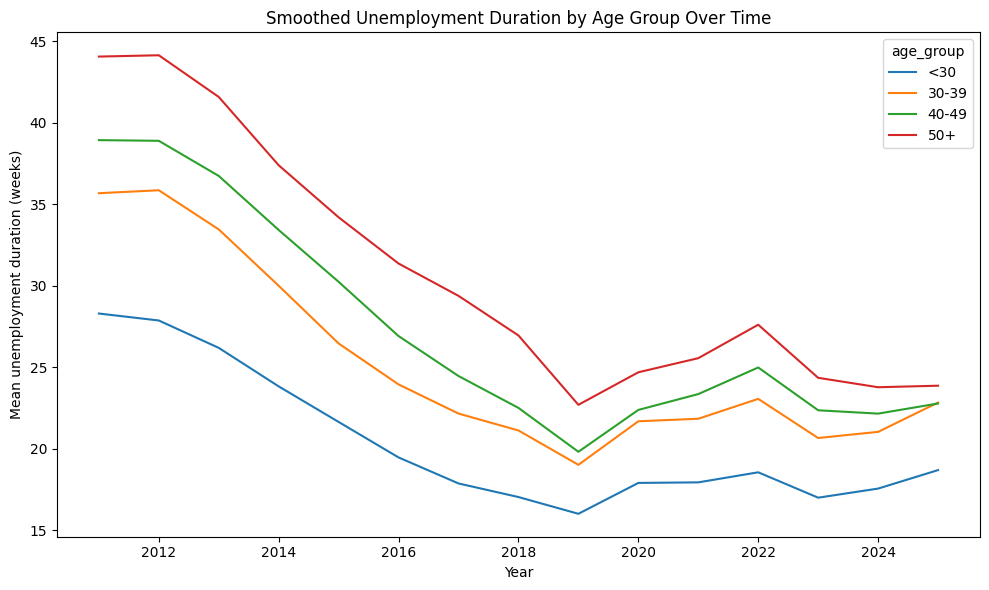

In [35]:
ax = pivot_age.rolling(3, center=True).mean().plot(
    title="Smoothed Unemployment Duration by Age Group Over Time",
    figsize=(10, 6)
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean unemployment duration (weeks)")
ax.figure.tight_layout()
ax.figure.savefig(FIG_DIR / "unemployment_duration_age_group_smoothed.png", dpi=300)

This figure shows that unemployment duration increases monotonically with age, with workers aged 50+ experiencing the longest job search durations.

Time trends are smoothed using a 3-year rolling average to reduce survey noise.

In [28]:
trend_career = unemployment_duration_by_group_over_time(df_clean, "career_stage")
pivot_career = trend_career.pivot(index="YEAR", columns="career_stage", values="mean_duration")
pivot_career

career_stage,22-32,33-42,43-52,52+
YEAR,,,,
2010,30.507832,34.274432,37.981806,40.785218
2011,32.668512,38.587319,42.087728,46.632591
2012,31.759048,37.144869,40.711425,46.658826
2013,29.890426,35.180934,37.396799,41.315152
2014,26.946159,31.040344,35.252928,38.889990
2015,23.200262,26.928637,30.287126,33.679121
2016,21.518302,24.241231,29.178931,31.081065
2017,19.632670,23.478655,25.927009,30.250607
2018,18.263734,20.908821,23.956776,27.139878


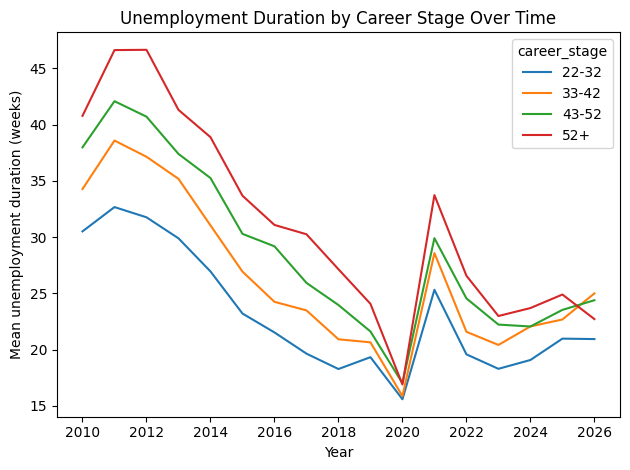

In [40]:
ax = pivot_career.plot(title="Unemployment Duration by Career Stage Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean unemployment duration (weeks)")
ax.figure.tight_layout()

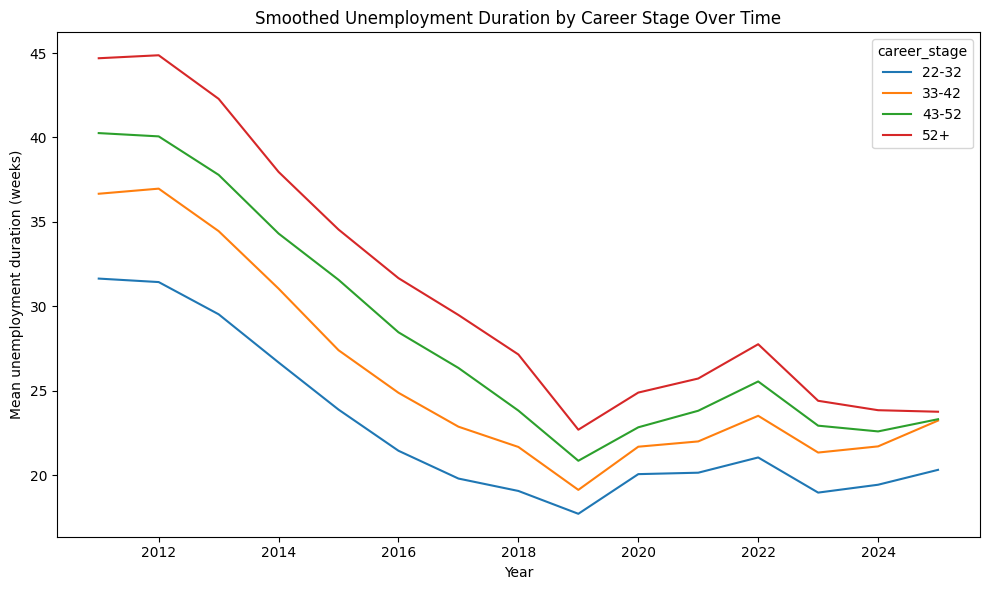

In [36]:
ax = pivot_career.rolling(3, center=True).mean().plot(
    title="Smoothed Unemployment Duration by Career Stage Over Time",
    figsize=(10, 6)
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean unemployment duration (weeks)")
ax.figure.tight_layout()
ax.figure.savefig(FIG_DIR / "unemployment_duration_career_stage_smoothed.png", dpi=300)

This figure shows again highlights the increased unemployment duration experienced by older workers, but it also highlights a departure that has been observed with workers in the middle of their career (a decade after graduation).

In [47]:
ratio = pivot_age.div(pivot_age['<30'], axis=0)
ratio

age_group,<30,30-39,40-49,50+
YEAR,,,,
2010,1.0,1.222236,1.327247,1.475771
2011,1.0,1.277697,1.406278,1.574080
2012,1.0,1.281027,1.391943,1.618703
2013,1.0,1.302785,1.387318,1.557186
2014,1.0,1.246009,1.432186,1.584790
2015,1.0,1.219546,1.388065,1.566506
2016,1.0,1.196628,1.363842,1.588366
2017,1.0,1.280142,1.396405,1.689849
2018,1.0,1.248613,1.344940,1.661325


Older workers remain unemployed ~1.4-1.6x longer than young workers.

## 5. Key Findings
* Older workers experience longer unemployment durations than younger workers across the full labor market.
* This pattern is persistent over time and remains visible after smoothing year-to-year volatility.
* When grouped into broader career stages, unemployment duration increases monotonically from early-career to late-career workers.
* These results suggest a structural disadvantage in re-employment for older workers, even though overall unemployment rates may be lower for older * age groups.
* This empirical pattern is consistent with the project’s experimental results showing that similarity-based screening can disadvantage more senior candidates even without explicit age features.

### Why this matters

These results show that older workers experience systematically longer job searches, even when accounting for macroeconomic conditions. This suggests structural barriers to re-employment, providing real-world context for the bias patterns observed in the model experiments.